In [1]:
import pymysql
import pandas as pd
from typing import Dict, Optional, Tuple
from DATA.stock_invest_function import get_db_host

In [17]:
def fetch_required_return_from_db(
    db_info: Dict[str, any],
    ticker: str,
    indicator: str = "Re_5y",
    table_name: str = "us_required_return_result"
) -> pd.DataFrame:
    """
    us_required_return_result 테이블에서 특정 ticker, indicator(Re_5y)의 시계열 추출

    return: DataFrame index=date, columns=['Re_5y']
    """
    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info.get("port", 3306),
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        sql = f"""
        SELECT date, value
        FROM {table_name}
        WHERE ticker=%s AND indicator=%s
        ORDER BY date
        """
        df = pd.read_sql(sql, conn, params=[ticker, indicator])
    finally:
        conn.close()

    if df.empty:
        raise ValueError(f"[Re] {ticker} / {indicator} 데이터가 없습니다.")

    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    df = df.rename(columns={"value": indicator})

    return df

def fetch_roe_from_sec_financial(
    db_info: Dict[str, any],
    ticker: str,
    item_name: str = "ROE",
    table_name: str = "sec_financial_data"
) -> pd.DataFrame:
    """
    sec_financial_data 에서 특정 ticker, item_name(ROE)의 시계열 추출

    return: DataFrame index=date, columns=['ROE']
    """
    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info.get("port", 3306),
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        sql = f"""
        SELECT date, value
        FROM {table_name}
        WHERE ticker=%s AND item_name=%s
        ORDER BY date
        """
        df = pd.read_sql(sql, conn, params=[ticker, item_name])
    finally:
        conn.close()

    if df.empty:
        raise ValueError(f"[ROE] {ticker} / {item_name} 데이터가 없습니다.")

    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    df = df.rename(columns={"value": item_name})

    # ROE가 % 단위(예: 12, 15 등)이면 0.x 로 스케일 조정
    med = df[item_name].median()
    if med > 1 and med < 100:
        df[item_name] = df[item_name] / 100.0

    return df

def get_latest_book_value_from_sec_financial(
    db_info: Dict[str, any],
    ticker: str,
    item_name: str = "stockholders_equity",
    table_name: str = "sec_financial_data"
) -> float:
    """
    sec_financial_data 테이블에서 특정 ticker 의 가장 최신 stockholders_equity 값을 반환.
    이 값은 RIM valuation 의 초기 book_value 로 사용됨.
    """

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info.get("port", 3306),
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        sql = f"""
        SELECT date, value
        FROM {table_name}
        WHERE ticker=%s AND item_name=%s
        ORDER BY date DESC
        LIMIT 1
        """
        df = pd.read_sql(sql, conn, params=[ticker, item_name])
    finally:
        conn.close()

    if df.empty:
        raise ValueError(f"[ERROR] {ticker}: stockholders_equity 최신 값이 없습니다.")

    book_value = float(df["value"].iloc[0])
    print(f"[INFO] {ticker} 최신 Book Value(stockholders_equity): {book_value:,.0f}")

    return book_value



def build_monthly_roe_re(
    db_info: Dict[str, any],
    ticker: str,
    re_indicator: str = "Re_5y",
    roe_item_name: str = "ROE"
) -> pd.DataFrame:
    """
    1) us_required_return_result 에서 Re_5y
    2) sec_financial_data 에서 ROE
    → 둘 다 월말 기준으로 resample 후 merge

    return: DataFrame index=date(月末), columns=['ROE','Re_5y','spread']
    """
    re_df = fetch_required_return_from_db(db_info, ticker, indicator=re_indicator)
    roe_df = fetch_roe_from_sec_financial(db_info, ticker, item_name=roe_item_name)

    # 월말 기준 resample (값이 없는 달은 직전값 유지)
    re_m  = re_df.resample("M").last().ffill()
    roe_m = roe_df.resample("M").last().ffill()

    merged = roe_m.join(re_m, how="inner")

    merged = merged.rename(columns={roe_item_name: "ROE", re_indicator: "Re_5y"})
    merged["spread"] = merged["ROE"] - merged["Re_5y"]

    return merged


def residual_income_valuation(
    initial_book_value: float,
    current_roe: float,
    required_return: float,
    payout_ratio: float = 0.3,
    n_high_years: int = 5,
    n_fade_years: int = 10,
    terminal_spread: float = 0.0
) -> Tuple[pd.DataFrame, float]:
    """
    단순 다단계 RIM 모형

    - 1 ~ n_high_years : ROE = current_roe
    - n_high_years+1 ~ n_high_years+n_fade_years :
        ROE가 선형으로 required_return + terminal_spread 로 수렴
    - 이후 기간의 RI 는 terminal_spread 를 반영한 '안정기 RI'의 영구가치로 처리

    return
    ------
    ri_table : 연도별 잔여이익 테이블
    fair_value : 주당 또는 총 자기자본 가치 (B0 + PV(RI))
    """

    T = n_high_years + n_fade_years  # 명시적으로 계산할 기간
    rows = []

    B_t = initial_book_value
    re = required_return

    # 안정기 ROE (fade 끝난 뒤의 수준)
    stable_roe = re + terminal_spread

    for t in range(1, T + 1):
        if t <= n_high_years:
            roe_t = current_roe
        else:
            # high → stable 선형 fade
            fade_pos = (t - n_high_years) / max(n_fade_years, 1)
            fade_pos = min(max(fade_pos, 0), 1)
            roe_t = current_roe * (1 - fade_pos) + stable_roe * fade_pos

        earnings_t = B_t * roe_t
        div_t = earnings_t * payout_ratio
        ri_t = (roe_t - re) * B_t
        B_next = B_t + earnings_t - div_t  # B_(t) → B_(t+1)

        disc = 1.0 / ((1 + re) ** t)
        pv_ri_t = ri_t * disc

        rows.append({
            "year": t,
            "begin_book": B_t,
            "ROE_t": roe_t,
            "earnings_t": earnings_t,
            "div_t": div_t,
            "end_book": B_next,
            "RI_t": ri_t,
            "discount_factor": disc,
            "PV_RI_t": pv_ri_t
        })

        B_t = B_next

    ri_table = pd.DataFrame(rows)
    pv_ri_sum = ri_table["PV_RI_t"].sum()

    # 안정기 이후 RI의 영구가치 (t = T+1부터 무한대까지)
    # 안정기 ROE = stable_roe, book = B_T
    B_T = ri_table.iloc[-1]["end_book"]
    stable_ri = (stable_roe - re) * B_T    # t = T+1 시점의 RI
    # t = T+1 부터 영구가치 → 시점 T 기준: stable_ri / re
    # 시점 0 기준 PV:
    tv_0 = (stable_ri / re) / ((1 + re) ** T)

    fair_value = initial_book_value + pv_ri_sum + tv_0

    # 테이블에 terminal value 정보도 추가
    ri_table["cum_PV_RI"] = ri_table["PV_RI_t"].cumsum()
    ri_table.attrs["terminal_value_PV0"] = tv_0
    ri_table.attrs["fair_value"] = fair_value

    return ri_table, fair_value

def show_roe_re_merged_table(
    db_info: Dict[str, any],
    ticker: str,
    re_indicator: str = "Re_5y",
    roe_item_name: str = "ROE",
    last_n: int = 24
) -> pd.DataFrame:
    """
    us_required_return_result(Re_5y) + sec_financial_data(ROE)를
    월말 기준으로 결합한 테이블을 확인하는 함수.

    Parameters
    ----------
    last_n : 최근 n개 월만 출력 (기본 24개월)

    Returns
    -------
    merged_monthly : index=월말(date), columns=['ROE','Re_5y','spread']
    """
    merged_monthly = build_monthly_roe_re(
        db_info=db_info,
        ticker=ticker,
        re_indicator=re_indicator,
        roe_item_name=roe_item_name
    )

    print("=" * 80)
    print(f"[INFO] {ticker} ROE / {re_indicator} 월말 결합 시계열 (최근 {last_n}개)")
    print("=" * 80)
    print(merged_monthly.tail(last_n))

    return merged_monthly


def run_rim_valuation_from_db(
    db_info: Dict[str, any],
    ticker: str,
    payout_ratio: float = 0.3,
    n_high_years: int = 5,
    n_fade_years: int = 10,
    terminal_spread: float = 0.0,
    re_indicator: str = "Re_5y",
    roe_item_name: str = "ROE"
) -> Tuple[pd.DataFrame, pd.DataFrame, float]:

    # -------------------------------------------------------
    # 1) 자동으로 최신 stockholders_equity 가져오기
    # -------------------------------------------------------
    book_value = get_latest_book_value_from_sec_financial(
        db_info=db_info,
        ticker=ticker,
        item_name="stockholders_equity"
    )

    # -------------------------------------------------------
    # 2) Re_5y & ROE 결합 월말 데이터 생성
    # -------------------------------------------------------
    merged_monthly = build_monthly_roe_re(
        db_info=db_info,
        ticker=ticker,
        re_indicator=re_indicator,
        roe_item_name=roe_item_name
    )

    latest = merged_monthly.dropna().iloc[-1]
    current_roe = float(latest["ROE"])
    required_return = float(latest["Re_5y"])

    print(f"[INFO] {ticker} 최신 월말 기준")
    print(f"       ROE      = {current_roe:.4f}")
    print(f"       Re_5y    = {required_return:.4f}")
    print(f"       spread   = {current_roe - required_return:.4f}")
    print(f"       Book Value = {book_value:,.0f}")

    # -------------------------------------------------------
    # 3) residual income valuation
    # -------------------------------------------------------
    ri_table, fair_value = residual_income_valuation(
        initial_book_value=book_value,
        current_roe=current_roe,
        required_return=required_return,
        payout_ratio=payout_ratio,
        n_high_years=n_high_years,
        n_fade_years=n_fade_years,
        terminal_spread=terminal_spread
    )

    return merged_monthly, ri_table, fair_value

import matplotlib.pyplot as plt

def rim_perpetual_spread_custom_g(
    book_value: float,
    roe: float,
    r: float,
    g: float,
) -> dict:
    """
    Perpetual Spread RIM
    - ROE - r 스프레드가 영구 지속
    - 성장률 g는 사용자가 직접 입력
    - r 은 '최신 요구수익률'을 그대로 사용 (수정/캡핑 안 함)

    V0 = B0 * [ 1 + (ROE - r) / (r - g) ]

    Args:
        book_value: B0, 현재 시점 장부가치
        roe: ROE (예: 0.15 → 15%)
        r: 요구수익률 (최근 r 값, 예: 0.10 → 10%)
        g: 장기 성장률 (사용자 지정, 예: 0.04 → 4%)

    Returns:
        dict:
            B0, ROE, r, g, spread, V0 등
    """

    s = roe - r  # 영구 스프레드

    # r <= g 인 경우도 그대로 계산하지만, 경고만 출력
    if r <= g:
        print("⚠ WARNING: r <= g 입니다. (r-g <= 0)")
        print(f"  r = {r:.4f}, g = {g:.4f}")
        print("  수렴 조건은 깨지지만, 입력된 r과 g를 그대로 사용해 V0를 계산합니다.\n")

    try:
        V0 = book_value * (1 + s / (r - g))
    except ZeroDivisionError:
        V0 = None
        print("⚠ ERROR: r - g = 0 이라서 분모가 0입니다. V0는 정의되지 않습니다.")

    return {
        "B0": book_value,
        "ROE": roe,
        "r": r,
        "g": g,
        "spread(ROE - r)": s,
        "r_minus_g": r - g,
        "value(V0)": V0,
    }

def plot_roe_re_spread(
    db_info: Dict[str, any],
    ticker: str,
    re_indicator: str = "Re_5y",
    roe_item_name: str = "ROE"
) -> None:
    """
    월말 기준 ROE, Re_5y, (ROE - Re_5y) 스프레드를 시각적으로 확인하는 함수.

    - 위쪽: ROE와 Re_5y (연율, 소수 → %로 표시)
    - 아래쪽: (ROE - Re_5y) 스프레드 (%p)

    Returns
    -------
    None (그래프만 출력)
    """
    merged = build_monthly_roe_re(
        db_info=db_info,
        ticker=ticker,
        re_indicator=re_indicator,
        roe_item_name=roe_item_name
    ).dropna()

    if merged.empty:
        print(f"[WARN] {ticker}: 결합된 ROE/Re 시계열이 없습니다.")
        return

    # % 단위로 보기 좋게 변환
    roe_pct = merged["ROE"] * 100.0
    re_pct  = merged["Re_5y"] * 100.0
    spread_pct = (merged["spread"]) * 100.0  # ROE - Re_5y

    dates = merged.index

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(12, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )

    # ---- (1) ROE vs Re_5y 라인 ----
    ax1.plot(dates, roe_pct, label="ROE (%)")
    ax1.plot(dates, re_pct, label=f"{re_indicator} (%)", linestyle="--")
    ax1.set_ylabel("ROE / Required Return (%)")
    ax1.set_title(f"{ticker} : ROE vs {re_indicator} (월말)")
    ax1.grid(True, linestyle=":")
    ax1.legend(loc="best")

    # ---- (2) spread = ROE - Re_5y ----
    ax2.axhline(0, color="black", linewidth=1)
    ax2.plot(dates, spread_pct, label="ROE - Re_5y (pct-point)")
    ax2.set_ylabel("Spread (p.p.)")
    ax2.set_xlabel("Date (Month End)")
    ax2.grid(True, linestyle=":")
    ax2.legend(loc="best")

    plt.tight_layout()
    plt.show()



In [131]:
db_info = {
    "host": get_db_host(),
    "port": 3307,
    "user": "stox7412",
    "password": "Apt106503!~",
    "database": "investar",
}

ticker = "AMZN"

In [132]:
merged = show_roe_re_merged_table(
    db_info=db_info,
    ticker= ticker,
    last_n=36  # 최근 3년만 보고 싶을 때
)


[INFO] AMZN ROE / Re_5y 월말 결합 시계열 (최근 36개)
                 ROE     Re_5y    spread
date                                    
2022-10-31  0.001209  0.109328 -0.108119
2022-11-30  0.001209  0.116389 -0.115180
2022-12-31 -0.000900  0.093558 -0.094458
2023-01-31 -0.000900  0.118419 -0.119320
2023-02-28 -0.000900  0.102071 -0.102972
2023-03-31  0.047746  0.120455 -0.072709
2023-04-30  0.047746  0.118212 -0.070466
2023-05-31  0.047746  0.113326 -0.065580
2023-06-30  0.104439  0.126102 -0.021663
2023-07-31  0.104439  0.128614 -0.024175
2023-08-31  0.104439  0.121819 -0.017380
2023-09-30  0.141502  0.118345  0.023157
2023-10-31  0.141502  0.112266  0.029236
2023-11-30  0.141502  0.140553  0.000949
2023-12-31  0.170615  0.152169  0.018446
2024-01-31  0.170615  0.143119  0.027496
2024-02-29  0.170615  0.149154  0.021461
2024-03-31  0.199032  0.149895  0.049137
2024-04-30  0.199032  0.146387  0.052645
2024-05-31  0.199032  0.150046  0.048986
2024-06-30  0.215648  0.149571  0.066077
2024-07-31  0.

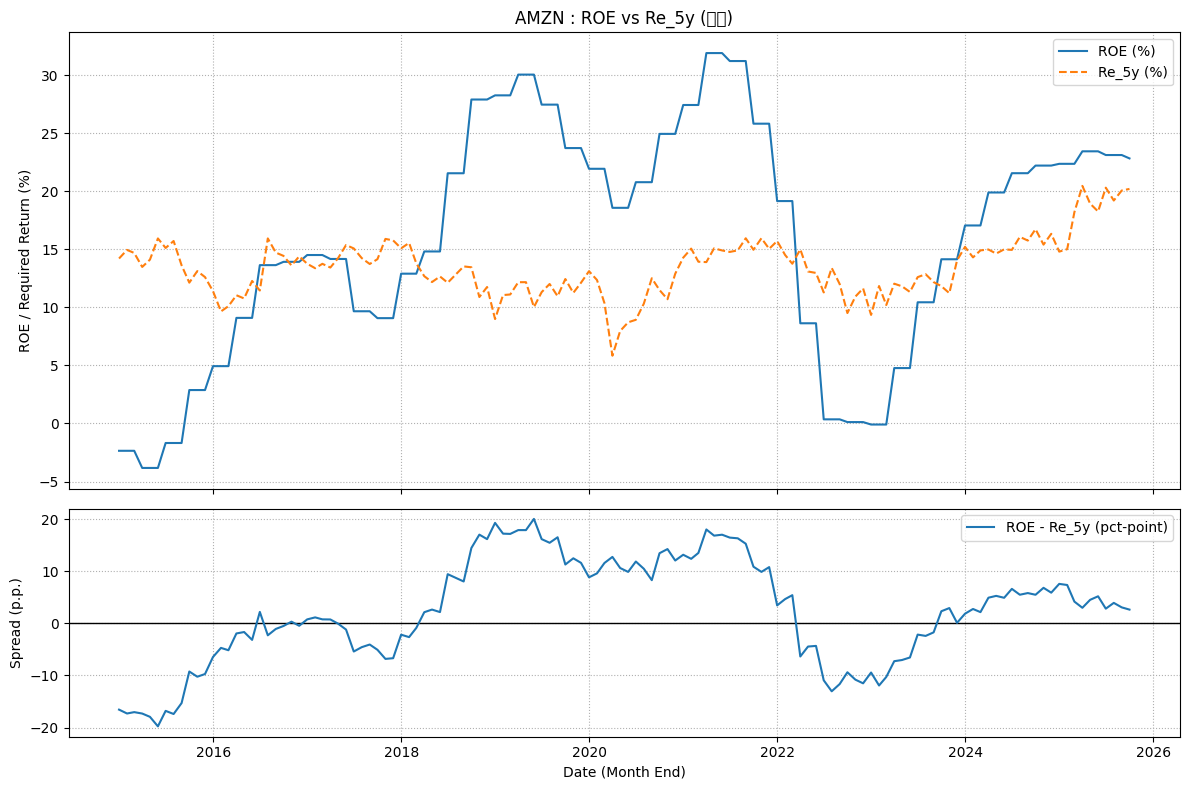

In [133]:
plot_roe_re_spread(
    db_info=db_info,
    ticker= ticker
)

In [134]:
merged_monthly, ri_table, fair_value = run_rim_valuation_from_db(
    db_info=db_info,
    ticker= ticker,
    payout_ratio=0.25,
    n_high_years=5,
    n_fade_years=30,
    terminal_spread=0.0
)

print("RIM Fair Value =", fair_value)
print(ri_table.head())

[INFO] AMZN 최신 Book Value(stockholders_equity): 369,631,000,000
[INFO] AMZN 최신 월말 기준
       ROE      = 0.2284
       Re_5y    = 0.2021
       spread   = 0.0263
       Book Value = 369,631,000,000
RIM Fair Value = 487582859197.9254
   year    begin_book     ROE_t    earnings_t         div_t      end_book  \
0     1  3.696310e+11  0.228397  8.442261e+10  2.110565e+10  4.329480e+11   
1     2  4.329480e+11  0.228397  9.888401e+10  2.472100e+10  5.071110e+11   
2     3  5.071110e+11  0.228397  1.158226e+11  2.895566e+10  5.939779e+11   
3     4  5.939779e+11  0.228397  1.356628e+11  3.391569e+10  6.957250e+11   
4     5  6.957250e+11  0.228397  1.589015e+11  3.972538e+10  8.149012e+11   

           RI_t  discount_factor       PV_RI_t     cum_PV_RI  
0  9.723190e+09         0.831883  8.088558e+09  8.088558e+09  
1  1.138875e+10         0.692030  7.881353e+09  1.596991e+10  
2  1.333962e+10         0.575688  7.679455e+09  2.364937e+10  
3  1.562467e+10         0.478905  7.482730e+09  3.1132

In [135]:
print(fair_value/1000000000)

487.5828591979254


In [123]:
B0 = 386867000000   # 현재 장부가치
roe = 0.35             # 15%
r   = 0.17            # 최신 요구수익률 9.5%
g   = 0.15             # 내가 가정한 장기 성장률 5%


res = rim_perpetual_spread_custom_g(B0, roe, r, g)
print(res)

{'B0': 386867000000, 'ROE': 0.35, 'r': 0.17, 'g': 0.15, 'spread(ROE - r)': 0.17999999999999997, 'r_minus_g': 0.020000000000000018, 'value(V0)': 3868669999999.9966}


In [124]:
res['value(V0)']/1000000000

3868.6699999999964

In [20]:
res

{'B0': 386867000000,
 'ROE': 0.3,
 'r': 0.14,
 'g': 0.05,
 'spread(ROE - r)': 0.15999999999999998,
 'r_minus_g': 0.09000000000000001,
 'value(V0)': 1074630555555.5553}